<a href="https://colab.research.google.com/github/manjunath1005/celebal-excellence-internship/blob/main/week3_Manjunath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, silhouette_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

# Dataset Loading

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/bank-customer-churn-prediction


In [3]:
import os
os.listdir(path)

['Churn_Modelling.csv']

In [4]:
df = pd.read_csv(path + '/Churn_Modelling.csv')

# Data Understanding & Initial Exploration

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df['Exited'].value_counts())

print("\nPercentage Distribution:")

print(df['Exited'].value_counts(normalize=True)*100)

Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage Distribution:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


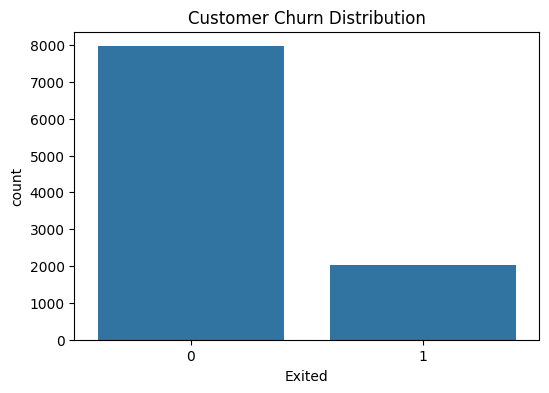

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Exited',data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Data Cleaning & Feature Engineering

In [11]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(df.shape)
df.head()

(10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Cleaning Pipeline

In [12]:
# Strip whitespace from all column names
df.columns = df.columns.str.strip()
print('Column names stripped:', list(df.columns))

# Force numeric types on all numeric columns
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f'Numeric types forced. Null count: {df.isnull().sum().sum()}')


Column names stripped: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Numeric types forced. Null count: 0


# Exploratory Data Analysis (EDA)

Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


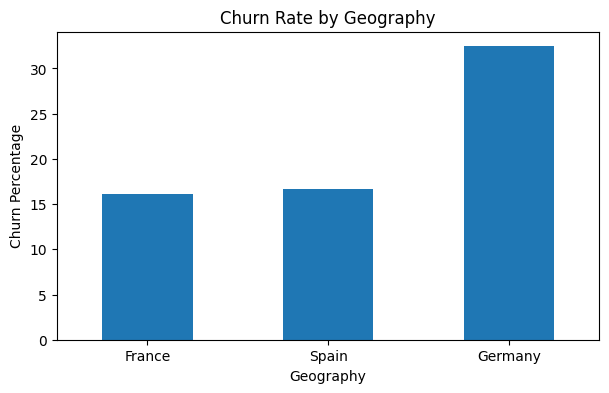

In [13]:
plt.figure(figsize=(7,4))

churn_geo = pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100
print(churn_geo)
churn_geo[1].sort_values().plot(kind='bar')
plt.ylabel('Churn Percentage')
plt.title('Churn Rate by Geography')
plt.xticks(rotation=0)
plt.show()


Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


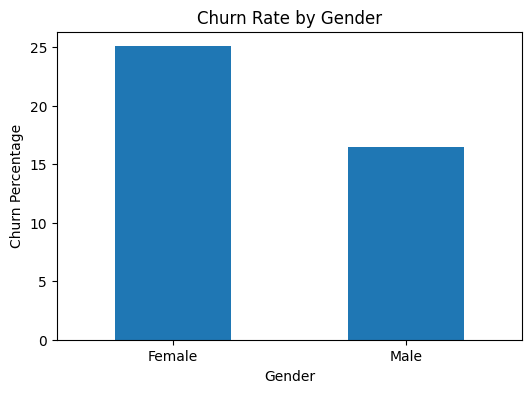

In [14]:
plt.figure(figsize=(6,4))

churn_gender = pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100
print(churn_gender)
churn_gender[1].plot(kind='bar')
plt.ylabel('Churn Percentage')
plt.title('Churn Rate by Gender')
plt.xticks(rotation=0)
plt.show()


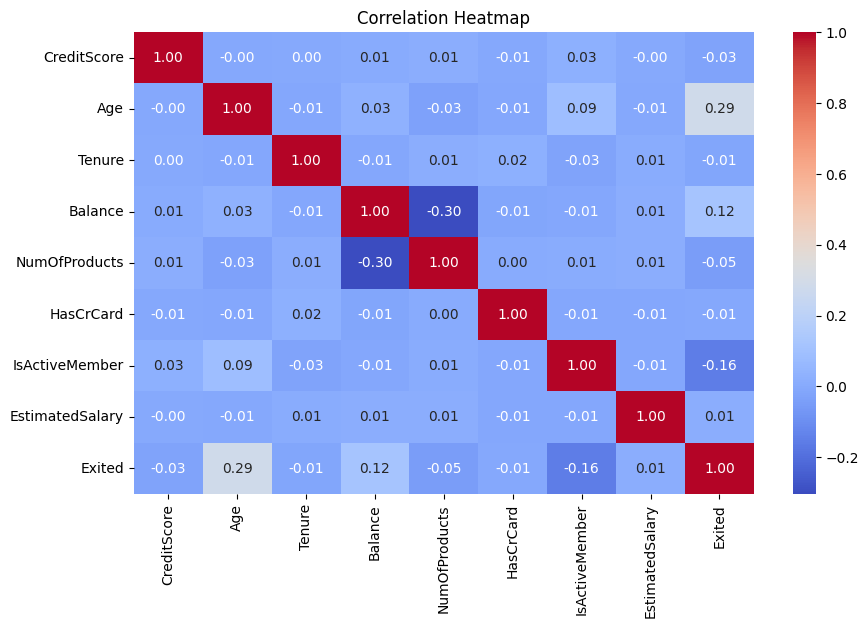

In [15]:
plt.figure(figsize=(10,6))

numeric_cols = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

In [16]:
# Gender Encoding
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Geography One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [17]:
df_encoded['Geography_Germany'] = df_encoded['Geography_Germany'].astype(int)
df_encoded['Geography_Spain'] = df_encoded['Geography_Spain'].astype(int)

df_encoded.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [18]:
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (10000, 11)
Target Shape : (10000,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTrain Distribution")
print(y_train.value_counts(normalize=True))
print("\nTest Distribution")
print(y_test.value_counts(normalize=True))

X_train: (8000, 11)
X_test : (2000, 11)

Train Distribution
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Test Distribution
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


# Feature Scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape :", X_test_scaled.shape)
print("\nFirst Row (first 5 values):")
print(X_train_scaled[0][:5])

Train Shape: (8000, 11)
Test Shape : (2000, 11)

First Row (first 5 values):
[ 1.058568    0.90750738  1.71508648  0.68472287 -1.22605881]


### Baseline Random Forest

In [21]:
rf_base_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_base_model.fit(X_train, y_train)
rf_pred = rf_base_model.predict(X_test)
rf_prob = rf_base_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))
print('ROC-AUC:', round(roc_auc_score(y_test, rf_prob), 4))

              precision    recall  f1-score   support

    Retained       0.87      0.96      0.92      1593
     Churned       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC: 0.8562


In [22]:
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': rf_base_model.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

feature_importance_rf.head(10)

,Feature,Importance
2,Age,0.238625
8,EstimatedSalary,0.146702
4,Balance,0.143858
0,CreditScore,0.143468
5,NumOfProducts,0.124600
3,Tenure,0.080964
7,IsActiveMember,0.041910
9,Geography_Germany,0.028054
6,HasCrCard,0.019027
1,Gender,0.018573


### Tuned Random Forest (RandomizedSearchCV)

In [23]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [6, 8, 10, 12, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 0.3, 0.4],
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv_strat,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", rf_search.best_score_)
print("\nBest Parameters:")
print(rf_search.best_params_)

Best CV ROC-AUC: 0.8610660592693897

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.4, 'max_depth': 8, 'class_weight': 'balanced'}


In [24]:
rf = rf_search.best_estimator_
y_prob_rf = rf.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.28, 0.55, 0.01)
f1_scores = [f1_score(y_test, (y_prob_rf >= t).astype(int)) for t in thresholds]
best_threshold_rf = thresholds[np.argmax(f1_scores)]
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

print("RANDOM FOREST — BEST MODEL")
print("Best Threshold:", best_threshold_rf)
print("\nAccuracy:", accuracy_score(y_test, y_pred_rf))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Retained','Churned']))

RANDOM FOREST — BEST MODEL
Best Threshold: 0.5300000000000002

Accuracy: 0.834

ROC-AUC: 0.8658165098843066

Classification Report:

              precision    recall  f1-score   support

    Retained       0.92      0.87      0.89      1593
     Churned       0.58      0.69      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000



### XGBoost (RandomizedSearchCV)

In [25]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pw = neg_count / pos_count
print("Scale Pos Weight:", scale_pw)

xgb_param_dist = {
    'n_estimators': [300, 400, 500, 600],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pw, random_state=42, eval_metric='auc', n_jobs=-1)
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=cv_strat,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
print("Best CV ROC-AUC:", xgb_search.best_score_)
print("\nBest Parameters:")
print(xgb_search.best_params_)

Scale Pos Weight: 3.9079754601226995
Best CV ROC-AUC: 0.8657241093700341

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [26]:
xgb = xgb_search.best_estimator_
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.28, 0.55, 0.01)
f1_scores = [f1_score(y_test, (y_prob_xgb >= t).astype(int)) for t in thresholds]
best_threshold_xgb = thresholds[np.argmax(f1_scores)]
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

print("XGBOOST — BEST MODEL")
print("Best Threshold:", best_threshold_xgb)
print("\nAccuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Retained','Churned']))

XGBOOST — BEST MODEL
Best Threshold: 0.5400000000000003

Accuracy: 0.8285

ROC-AUC: 0.8671444942631382

Classification Report:

              precision    recall  f1-score   support

    Retained       0.92      0.85      0.89      1593
     Churned       0.56      0.72      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



### 5-Fold Cross-Validation

In [27]:
models = {"Random Forest": rf, "XGBoost": xgb,}

print("5-Fold Cross-Validation Scores (ROC-AUC):")
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv_strat,
        scoring='roc_auc',
        n_jobs=-1
    )

    print(f"{name:<20} | AUC: Mean - {scores.mean():.4f}, Std - {scores.std():.4f}")

5-Fold Cross-Validation Scores (ROC-AUC):
Random Forest        | AUC: Mean - 0.8611, Std - 0.0106
XGBoost              | AUC: Mean - 0.8657, Std - 0.0099


### Model Comparison

In [28]:
results = pd.DataFrame({
    'Model':   ['Random Forest', 'XGBoost'],
    'CV AUC':  [0.8611, 0.8657],
    'Test AUC':[round(roc_auc_score(y_test, y_prob_rf), 4),
                round(roc_auc_score(y_test, y_prob_xgb), 4)],
    'Accuracy':[round(accuracy_score(y_test, y_pred_rf), 4),
                round(accuracy_score(y_test, y_pred_xgb), 4)],
})
results.sort_values(by='CV AUC', ascending=False)

,Model,CV AUC,Test AUC,Accuracy
1,XGBoost,0.8657,0.8671,0.8285
0,Random Forest,0.8611,0.8658,0.8340


## Customer Segmentation (Clustering)

In [30]:
cluster_features = df_encoded[[
    'Age',
    'Balance',
    'NumOfProducts',
    'IsActiveMember',
    'Geography_Germany',
    'Geography_Spain'
]]

print('Clustering features selected:', list(cluster_features.columns))
print('Shape:', cluster_features.shape)

Clustering features selected: ['Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain']
Shape: (10000, 6)


In [31]:
scaler_fs = StandardScaler()
cluster_scaled_fs = scaler_fs.fit_transform(cluster_features)
print(cluster_scaled_fs.shape)

(10000, 6)


In [32]:
pca_fs = PCA(n_components=2, random_state=42)
X_pca_fs = pca_fs.fit_transform(cluster_scaled_fs)

print("Explained Variance:",round(pca_fs.explained_variance_ratio_.sum(),4))

Explained Variance: 0.4623


k=2 --> Silhouette = 0.4109
k=3 --> Silhouette = 0.4475
k=4 --> Silhouette = 0.4410
k=5 --> Silhouette = 0.4596
k=6 --> Silhouette = 0.4791
k=7 --> Silhouette = 0.5019
k=8 --> Silhouette = 0.5011
k=9 --> Silhouette = 0.5156
k=10 --> Silhouette = 0.5014


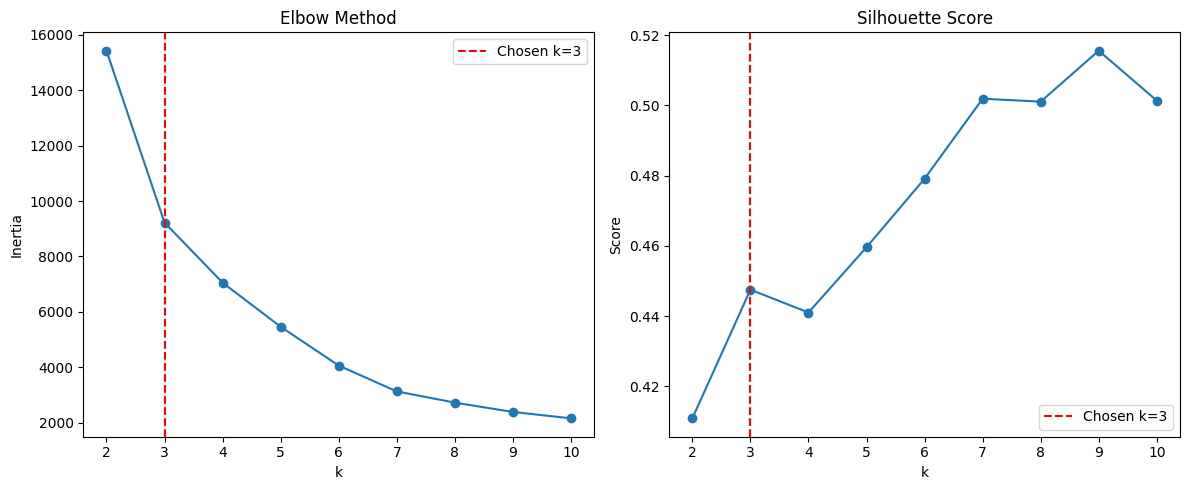

In [33]:
k_values = range(2, 11)
inertia = []
silhouette = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca_fs)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_pca_fs, labels))
    print(f'k={k} --> Silhouette = {silhouette[-1]:.4f}')

# Chosen k
best_k = 3

# Plot
plt.figure(figsize=(12,5))

# Elbow Plot
plt.subplot(1,2,1)
plt.plot(k_values, inertia, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Chosen k={best_k}')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.legend()

# Silhouette Plot
plt.subplot(1,2,2)
plt.plot(k_values, silhouette, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Chosen k={best_k}')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

**K Selection**

Based on the project instructions, k = 3 was chosen for K-Means clustering. The Elbow Method and Silhouette analysis also showed that k = 3 provides a reasonable balance between cluster quality and interpretability. Three customer segments are easier to understand and act upon compared to a larger number of clusters.

### K-Means Clustering (k=3)

In [34]:
best_k = 3

kmeans_fs = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_fs = kmeans_fs.fit_predict(X_pca_fs)
final_sil = silhouette_score(X_pca_fs, labels_fs)
print("Final Silhouette:", round(final_sil,4))

Final Silhouette: 0.4475


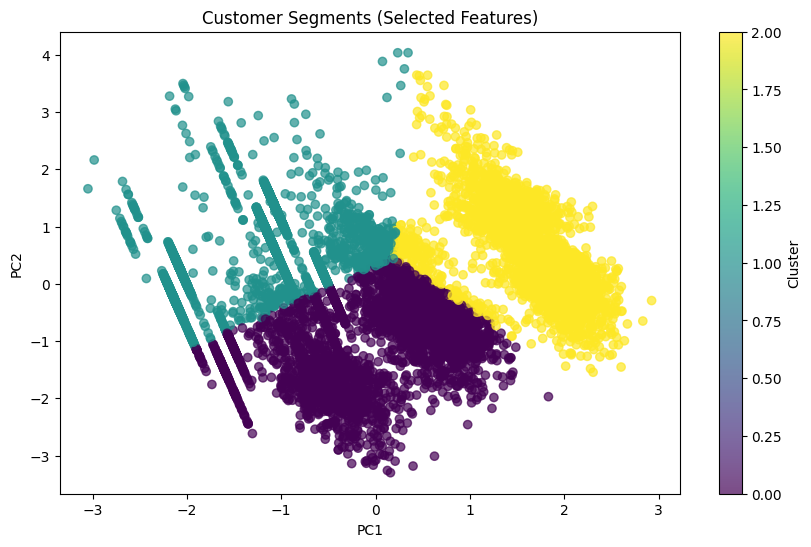

In [35]:
plt.figure(figsize=(10,6))

plt.scatter(X_pca_fs[:,0], X_pca_fs[:,1], c=labels_fs, cmap='viridis', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (Selected Features)")
plt.colorbar(label="Cluster")
plt.show()

### DBSCAN Clustering

In [36]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca_fs)
n_req = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_req = (dbscan_labels == -1).sum()
print('  DBSCAN Suggested (eps=1.5, min_samples=5)')
print(f'Clusters found : {n_req}')
print(f'Noise points   : {n_noise_req}')



  DBSCAN Suggested (eps=1.5, min_samples=5)
Clusters found : 1
Noise points   : 0


In [37]:
# Optimized configuration — eps=0.25
dbscan_opt = DBSCAN(eps=0.25, min_samples=5)
dbscan_opt_labels = dbscan_opt.fit_predict(X_pca_fs)
n_opt = len(set(dbscan_opt_labels)) - (1 if -1 in dbscan_opt_labels else 0)
n_noise_opt = (dbscan_opt_labels == -1).sum()
print('  DBSCAN Optimized (eps=0.25, min_samples=5)')
print(f'Clusters found : {n_opt}')
print(f'Noise points   : {n_noise_opt}')

  DBSCAN Optimized (eps=0.25, min_samples=5)
Clusters found : 2
Noise points   : 29


In [38]:
unique_o, counts_o = np.unique(dbscan_opt_labels, return_counts=True)
for lb, ct in zip(unique_o, counts_o):
    name = 'Noise' if lb == -1 else f'Cluster {lb}'
    print(f'{name}: {ct} ({ct/len(dbscan_opt_labels)*100:.1f}%)')
if n_opt > 1:
    mask = dbscan_opt_labels != -1
    sil_db = silhouette_score(X_pca_fs[mask], dbscan_opt_labels[mask])
    print(f'Silhouette Score: {sil_db:.4f}')

Noise: 29 (0.3%)
Cluster 0: 9964 (99.6%)
Cluster 1: 7 (0.1%)
Silhouette Score: 0.4478


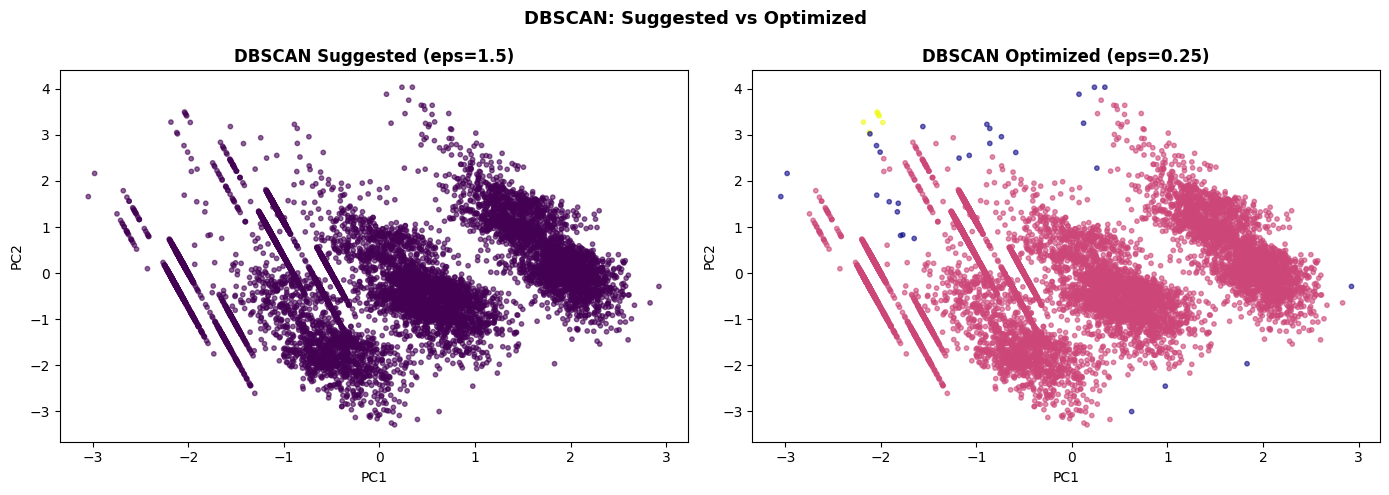

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca_fs[:,0], X_pca_fs[:,1], c=dbscan_labels, cmap='viridis', alpha=0.6, s=10)
axes[0].set_title('DBSCAN Suggested (eps=1.5)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[1].scatter(X_pca_fs[:,0], X_pca_fs[:,1], c=dbscan_opt_labels, cmap='plasma', alpha=0.6, s=10)
axes[1].set_title('DBSCAN Optimized (eps=0.25)', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.suptitle('DBSCAN: Suggested vs Optimized', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Observations

### 1. High-Risk Customer Segment

K-Means clustering identified a customer segment with the highest churn rate (~32%). These customers have relatively high balances but are more likely to leave the bank. Targeted retention campaigns should focus on this group.

---

### 2. Product Ownership Improves Retention

Customers with more banking products showed much lower churn rates (~12%). This suggests that increasing product adoption can improve customer loyalty and retention.

---

### 3. Geography Impacts Churn

Customers from Germany had the highest churn rate (32%), compared to France (16%) and Spain (17%). Region-specific retention strategies may help reduce customer loss.

---

### 4. XGBoost Performed Best

XGBoost achieved the highest ROC-AUC score (0.8671) and identified churning customers effectively, making it the best model for churn prediction in this project.

---

### 5. K-Means Produced Better Customer Segments

K-Means generated three meaningful customer segments with a silhouette score of 0.4475. DBSCAN did not produce well-balanced clusters, so K-Means was selected as the final segmentation model.

